# Compare Zero-Shot Classification Results

In [1]:
datasets = {
    "Adaptyv - Qwen3.8-27B": "scored_df_adaptyv_Qwen3.8-27B.csv",
    "Adaptyv - Qwen3.6-35B-A3B": "scored_df_adaptyv_Qwen3.6-35B-A3B.csv",
    "Twist - Qwen3.8-27B": "scored_df_twist_Qwen3.8-27B.csv",
    "Twist - Qwen3.6-35B-A3B": "scored_df_twist_Qwen3.6-35B-A3B.csv"
}

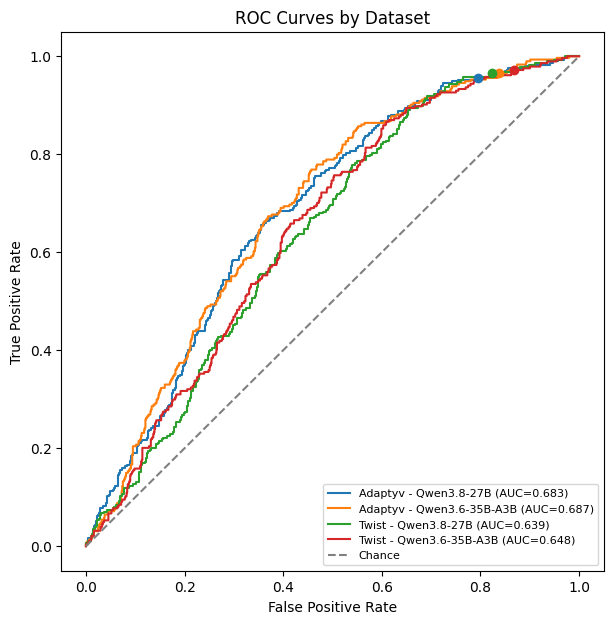

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 7))

for label, path in datasets.items():
    df = pd.read_csv(path)
    y_true = (df["y_true"] == "binder").astype(int)
    y_pred = (df["y_pred"] == "binder").astype(int)

    fpr, tpr, _ = roc_curve(y_true, df["p_binder"])
    auc = roc_auc_score(y_true, df["p_binder"])

    ## operating point implied by the model's thresholded y_pred
    op_fpr = ((y_pred == 1) & (y_true == 0)).sum() / max((y_true == 0).sum(), 1)
    op_tpr = ((y_pred == 1) & (y_true == 1)).sum() / max((y_true == 1).sum(), 1)

    line, = ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
    ax.scatter([op_fpr], [op_tpr], color=line.get_color(), zorder=3)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves by Dataset")
ax.legend(loc="lower right", fontsize=8)
plt.show()

In [4]:
import numpy as np
from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
)

rows = []
for label, path in datasets.items():
    df = pd.read_csv(path)
    y_true = (df["y_true"] == "binder").astype(int)

    precision, recall, thresholds = precision_recall_curve(y_true, df["p_binder"])
    f1 = np.where(precision + recall > 0, 2 * precision * recall / (precision + recall + 1e-12), 0)
    best_idx = f1[:-1].argmax()  ## last point has no associated threshold
    best_threshold = thresholds[best_idx]

    y_pred = (df["p_binder"] >= best_threshold).astype(int)
    rows.append({
        "dataset": label,
        "best_threshold": best_threshold,
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        ## imbalance-robust: averages per-class recall / corrects for chance agreement
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    })

metrics_df = pd.DataFrame(rows).set_index("dataset")
metrics_df

,best_threshold,precision,recall,accuracy,balanced_accuracy,mcc,f1
dataset,,,,,,,
Adaptyv - Qwen3.8-27B,0.895213,0.377551,0.755102,0.595194,0.645318,0.259557,0.503401
Adaptyv - Qwen3.6-35B-A3B,0.967577,0.366812,0.857143,0.559150,0.652556,0.281916,0.513761
Twist - Qwen3.8-27B,0.768005,0.322335,0.894366,0.485871,0.618770,0.231312,0.473881
Twist - Qwen3.6-35B-A3B,0.965387,0.331984,0.866197,0.514129,0.628671,0.240757,0.480000


In [5]:
## Balanced accuracy per target, using each dataset's best threshold from above
target_rows = []
for label, path in datasets.items():
    df = pd.read_csv(path)
    y_true = (df["y_true"] == "binder").astype(int)
    best_threshold = metrics_df.loc[label, "best_threshold"]
    y_pred = (df["p_binder"] >= best_threshold).astype(int)

    for target, group_idx in df.groupby("target").groups.items():
        target_rows.append({
            "dataset": label,
            "target": target,
            "balanced_accuracy": balanced_accuracy_score(y_true[group_idx], y_pred[group_idx]),
            "n": len(group_idx),
        })

target_balanced_acc = pd.DataFrame(target_rows)
target_balanced_acc_pivot = target_balanced_acc.pivot(index="target", columns="dataset", values="balanced_accuracy")
target_balanced_acc_pivot

C:\Users\Colby\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Colby\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


dataset,Adaptyv - Qwen3.6-35B-A3B,Adaptyv - Qwen3.8-27B,Twist - Qwen3.6-35B-A3B,Twist - Qwen3.8-27B
target,,,,
15-PGDH,0.839286,0.392857,0.844828,0.293103
BBF-14,0.279221,0.318182,0.603922,0.609804
BHRF1,0.531915,0.563830,0.531915,0.542553
Cas9,0.666209,0.500000,0.604167,0.639881
EGFR,0.510654,0.592085,0.635464,0.649163
IL-7Ra,0.542424,0.557576,0.569820,0.546010
Latent GDF-8,0.692308,0.500000,NaN,NaN
MBP,0.279070,0.337209,0.623529,0.611765
Nipah-G,0.668159,0.708440,0.649596,0.669811
